#Importing Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from PIL import Image
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

In [2]:
import os
from zipfile import ZipFile

Extracting Dataset

In [3]:
dataset = '/content/Dataset.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Extracted')

Extracted


In [4]:
!ls

Dataset  Dataset.zip  sample_data


In [5]:
dirs,path,files = next(os.walk('/content/Dataset'))
file_count = len(files)

print('The size of file is : ',file_count)

The size of file is :  1656


Checking Example Image

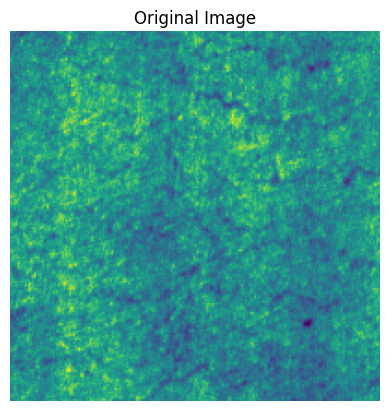

In [6]:
img = mpimg.imread('/content/Dataset/Cr_120.bmp')
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

#Image Processing

Creating Resized image Dictionary

In [7]:
from os.path import exists
#creating directory for resized images

os.makedirs('/content/image resized',exist_ok = True)

In [8]:
original_folder = '/content/Dataset'
resized_folder = '/content/image resized'

files = os.listdir(original_folder)

for i in range(len(files)):

    filename = files[i]
    img_path = os.path.join(original_folder, filename)

    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    newImg_Path = os.path.join(resized_folder, filename)
    img.save(newImg_Path)

Checking Resized Image

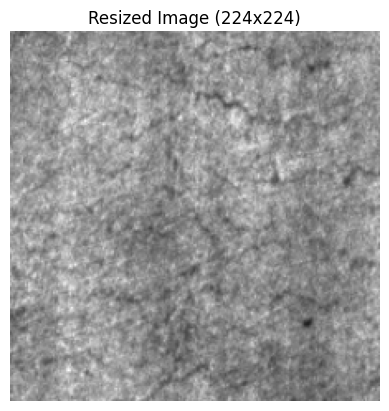

In [9]:
img_compress = mpimg.imread('/content/image resized/Cr_120.bmp')
plt.imshow(img_compress)
plt.title("Resized Image (224x224)")
plt.axis("off")
plt.show()

Creating Labels

In [10]:
folder = '/content/image resized'
file_names = sorted(os.listdir(folder))

labels = []

for filename in file_names:

    prefix = filename[:2].lower()
    if prefix == 'cr':
        labels.append(1)
    else:
        labels.append(0)

Class Distribution Graph

Class distribution (label: count) -> {np.int64(0): np.int64(1380), np.int64(1): np.int64(276)}


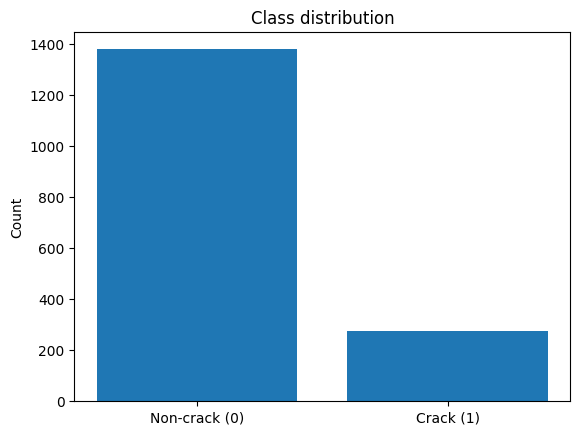

In [11]:
labels_np = np.array(labels)

try:
    del zip
except:
    pass


unique, counts = np.unique(labels_np, return_counts=True)
print("Class distribution (label: count) ->", dict(zip(unique, counts)))

plt.bar(['Non-crack (0)', 'Crack (1)'], counts)
plt.title("Class distribution")
plt.ylabel("Count")
plt.show()

In [12]:
!ls

 Dataset   Dataset.zip	'image resized'   sample_data


In [13]:
file_names[0:5]

['Cr_120.bmp', 'Cr_121.bmp', 'Cr_122.bmp', 'Cr_123.bmp', 'Cr_124.bmp']

In [14]:
labels[0:5]

[1, 1, 1, 1, 1]

In [15]:
values,count = np.unique(labels,return_counts=True)

In [16]:
print(values,count)

[0 1] [1380  276]


Converting images to numpy array

In [17]:
import cv2

In [18]:
image_paths = [os.path.join(folder, fname) for fname in file_names]

images = []
for p in image_paths:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

images = np.asarray(images)
print("Images shape:", images.shape)

Images shape: (1656, 224, 224, 3)


In [19]:
# image_directory = '/content/image resized'
# image_extension = ['png','jpg','bmp']

# files = []

# [files.extend(glob.glob(image_directory + '/*.' + e)) for e in image_extension]

# images = np.asarray([cv2.imread(file) for file in files])

In [20]:
print(images)

[[[[142 142 142]
   [133 133 133]
   [129 129 129]
   ...
   [149 149 149]
   [160 160 160]
   [171 171 171]]

  [[110 110 110]
   [125 125 125]
   [121 121 121]
   ...
   [147 147 147]
   [163 163 163]
   [193 193 193]]

  [[114 114 114]
   [116 116 116]
   [ 92  92  92]
   ...
   [157 157 157]
   [160 160 160]
   [181 181 181]]

  ...

  [[159 159 159]
   [170 170 170]
   [151 151 151]
   ...
   [143 143 143]
   [137 137 137]
   [128 128 128]]

  [[128 128 128]
   [141 141 141]
   [150 150 150]
   ...
   [140 140 140]
   [141 141 141]
   [138 138 138]]

  [[122 122 122]
   [137 137 137]
   [139 139 139]
   ...
   [149 149 149]
   [147 147 147]
   [121 121 121]]]


 [[[143 143 143]
   [139 139 139]
   [136 136 136]
   ...
   [ 57  57  57]
   [ 54  54  54]
   [ 46  46  46]]

  [[129 129 129]
   [122 122 122]
   [128 128 128]
   ...
   [ 59  59  59]
   [ 52  52  52]
   [ 47  47  47]]

  [[118 118 118]
   [121 121 121]
   [127 127 127]
   ...
   [ 63  63  63]
   [ 50  50  50]
   [ 47  47

In [21]:
images.shape

(1656, 224, 224, 3)

In [22]:
x = images
y = np.asarray(labels)

Train Test Split

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)

In [24]:
x_train

array([[[[150, 150, 150],
         [160, 160, 160],
         [149, 149, 149],
         ...,
         [ 82,  82,  82],
         [ 83,  83,  83],
         [ 82,  82,  82]],

        [[163, 163, 163],
         [164, 164, 164],
         [150, 150, 150],
         ...,
         [ 84,  84,  84],
         [ 84,  84,  84],
         [ 85,  85,  85]],

        [[160, 160, 160],
         [157, 157, 157],
         [145, 145, 145],
         ...,
         [ 81,  81,  81],
         [ 83,  83,  83],
         [ 80,  80,  80]],

        ...,

        [[158, 158, 158],
         [154, 154, 154],
         [171, 171, 171],
         ...,
         [ 92,  92,  92],
         [ 93,  93,  93],
         [ 94,  94,  94]],

        [[160, 160, 160],
         [158, 158, 158],
         [176, 176, 176],
         ...,
         [ 93,  93,  93],
         [ 94,  94,  94],
         [ 91,  91,  91]],

        [[159, 159, 159],
         [155, 155, 155],
         [171, 171, 171],
         ...,
         [ 92,  92,  92],
        

In [25]:
x_train = x_train/255.0
x_test = x_test/255.0

In [26]:
x_train.shape

(1324, 224, 224, 3)

#Model-1(MobileNet)

In [27]:
import tensorflow as tf
import tensorflow_hub as hub

In [28]:
!pip install tf_keras
import tf_keras

In [29]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model,
                                  input_shape=(224,224,3),
                                  trainable=False)

In [30]:
num_of_classes = 2

model = tf_keras.Sequential([
    pretrained_model,
    tf_keras.layers.Dense(num_of_classes,activation='softmax')
])

In [31]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [32]:
model.compile(
    optimizer = 'adam',
    loss = tf_keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['acc']
)

In [33]:
history = model.fit(x_train,y_train,epochs = 5,validation_data=(x_test,y_test))

Epoch 1/5
42/42 [==============================] - 18s 135ms/step - loss: 0.2718 - acc: 0.8943 - val_loss: 0.0617 - val_acc: 0.9849
Epoch 2/5
42/42 [==============================] - 3s 63ms/step - loss: 0.0445 - acc: 0.9909 - val_loss: 0.0325 - val_acc: 0.9970
Epoch 3/5
42/42 [==============================] - 3s 79ms/step - loss: 0.0257 - acc: 0.9977 - val_loss: 0.0222 - val_acc: 0.9970
Epoch 4/5
42/42 [==============================] - 3s 69ms/step - loss: 0.0178 - acc: 0.9992 - val_loss: 0.0173 - val_acc: 0.9970
Epoch 5/5
42/42 [==============================] - 2s 50ms/step - loss: 0.0131 - acc: 1.0000 - val_loss: 0.0137 - val_acc: 0.9970


#Model Evaluation-1

In [34]:
h = history

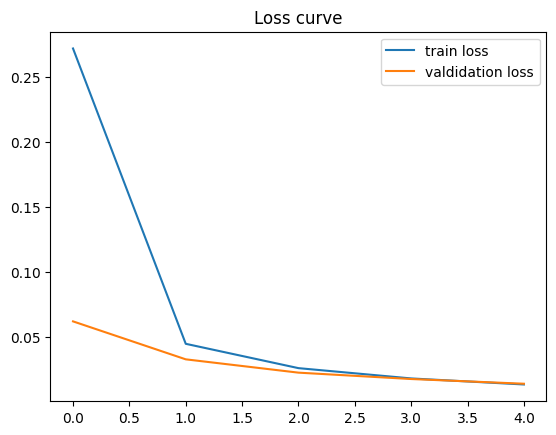

In [35]:
#plot loss value
plt.plot(h.history['loss'],label = 'train loss')
plt.plot(h.history['val_loss'],label = 'valdidation loss')
plt.legend()
plt.title("Loss curve")
plt.show()

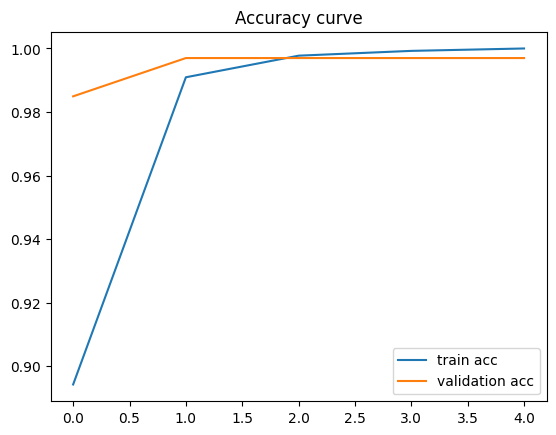

In [36]:
#plot accuracy value
plt.plot(h.history['acc'],label = 'train acc')
plt.plot(h.history['val_acc'],label = 'validation acc')
plt.legend()
plt.title("Accuracy curve")
plt.show()

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [38]:
#Test Accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0137
Test Accuracy: 0.9970


In [39]:
# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

11/11 [==============================] - 1s 36ms/step


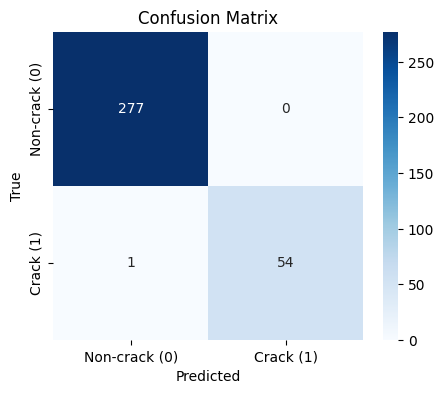

In [40]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-crack (0)', 'Crack (1)'],
            yticklabels=['Non-crack (0)', 'Crack (1)'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-crack', 'Crack']))

Classification Report:
              precision    recall  f1-score   support

   Non-crack       1.00      1.00      1.00       277
       Crack       1.00      0.98      0.99        55

    accuracy                           1.00       332
   macro avg       1.00      0.99      0.99       332
weighted avg       1.00      1.00      1.00       332



#Model-2(Custom CNN)

In [42]:
import tensorflow as tf
import tf_keras

model2 = tf_keras.Sequential([
    tf_keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf_keras.layers.MaxPooling2D(2,2),

    tf_keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf_keras.layers.MaxPooling2D(2,2),

    tf_keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf_keras.layers.MaxPooling2D(2,2),

    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(128, activation='relu'),
    tf_keras.layers.Dropout(0.3),
    tf_keras.layers.Dense(2, activation='softmax')
])

In [43]:
model2.summary()

model2.compile(
    optimizer='adam',
    loss=tf_keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['acc']
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)      

In [44]:
history2 = model2.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
42/42 [==============================] - 7s 76ms/step - loss: 0.6571 - acc: 0.8172 - val_loss: 0.4288 - val_acc: 0.8343
Epoch 2/10
42/42 [==============================] - 2s 52ms/step - loss: 0.4768 - acc: 0.8331 - val_loss: 0.3951 - val_acc: 0.8343
Epoch 3/10
42/42 [==============================] - 2s 54ms/step - loss: 0.4494 - acc: 0.8331 - val_loss: 0.3721 - val_acc: 0.8343
Epoch 4/10
42/42 [==============================] - 2s 56ms/step - loss: 0.3818 - acc: 0.8331 - val_loss: 0.3380 - val_acc: 0.8343
Epoch 5/10
42/42 [==============================] - 2s 52ms/step - loss: 0.3055 - acc: 0.8331 - val_loss: 0.2173 - val_acc: 0.8343
Epoch 6/10
42/42 [==============================] - 2s 55ms/step - loss: 0.2653 - acc: 0.8331 - val_loss: 0.1759 - val_acc: 0.8343
Epoch 7/10
42/42 [==============================] - 2s 52ms/step - loss: 0.1613 - acc: 0.9011 - val_loss: 0.1021 - val_acc: 0.9729
Epoch 8/10
42/42 [==============================] - 2s 53ms/step - loss: 0.1015 - a

#Model Evaluation-2

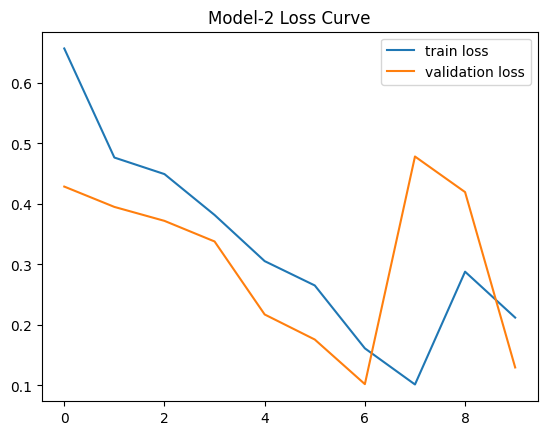

In [45]:
plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='validation loss')
plt.legend()
plt.title("Model-2 Loss Curve")
plt.show()

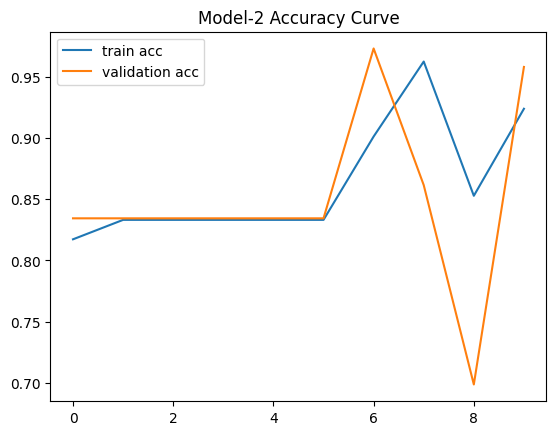

In [46]:
plt.plot(history2.history['acc'], label='train acc')
plt.plot(history2.history['val_acc'], label='validation acc')
plt.legend()
plt.title("Model-2 Accuracy Curve")
plt.show()

In [47]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f"Model-2 Test Loss: {test_loss2:.4f}")
print(f"Model-2 Test Accuracy: {test_acc2:.4f}")

Model-2 Test Loss: 0.1297
Model-2 Test Accuracy: 0.9578


In [48]:
y_pred_probs2 = model2.predict(x_test)
y_pred2 = np.argmax(y_pred_probs2, axis=1)

11/11 [==============================] - 0s 16ms/step


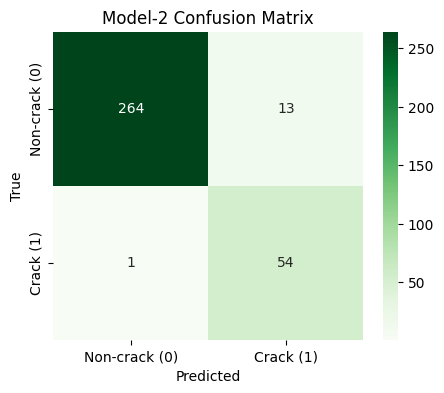

In [49]:
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-crack (0)', 'Crack (1)'],
            yticklabels=['Non-crack (0)', 'Crack (1)'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-2 Confusion Matrix")
plt.show()

In [50]:
print("Model-2 Classification Report:")
print(classification_report(y_test, y_pred2, target_names=['Non-crack', 'Crack']))

Model-2 Classification Report:
              precision    recall  f1-score   support

   Non-crack       1.00      0.95      0.97       277
       Crack       0.81      0.98      0.89        55

    accuracy                           0.96       332
   macro avg       0.90      0.97      0.93       332
weighted avg       0.96      0.96      0.96       332



#Deployment Ready

In [51]:
model.save("/content/crack_detector_mobilenet.h5")
print("Model saved successfully!")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully!


In [52]:
loaded_model = tf_keras.models.load_model(
    "/content/crack_detector_mobilenet.h5",
    custom_objects={'KerasLayer': hub.KerasLayer}
)

print("Model loaded successfully!")

Model loaded successfully!


Predictive System

In [53]:
def predict_image(path):
    img = Image.open(path).resize((224,224)).convert("RGB")
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = loaded_model.predict(img_array)
    label = np.argmax(preds)

    plt.imshow(img)
    plt.title(f"Prediction: {'Crack' if label==1 else 'Non-crack'}")
    plt.axis('off')
    plt.show()

    return preds

# Example usage:
# predict_image("/content/image resized/Cr_120.bmp")


1/1 [==============================] - 1s 826ms/step


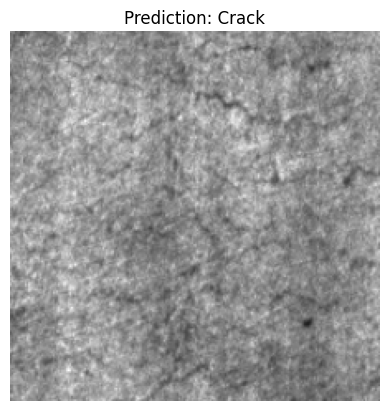

array([[0.00254713, 0.9974529 ]], dtype=float32)

In [54]:
predict_image('/content/image resized/Cr_120.bmp')

#GradCam

In [55]:
import tensorflow as tf

gradcam_backbone = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [56]:
def make_gradcam_heatmap(img_array, last_conv_layer_name="Conv_1"):
    # Get last conv layer
    last_conv_layer = gradcam_backbone.get_layer(last_conv_layer_name)

    # Build grad model for Grad-CAM
    grad_model = tf.keras.models.Model(
        inputs=gradcam_backbone.input,
        outputs=[last_conv_layer.output, gradcam_backbone.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pooled_grads = tf.reduce_mean(tape.gradient(predictions, conv_outputs), axis=(0,1,2))

    # Weighted sum
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

In [57]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def show_gradcam(path):
    img = Image.open(path).resize((224,224)).convert("RGB")
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, 0)

    heatmap = make_gradcam_heatmap(img_array)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(np.array(img), 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(superimposed)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

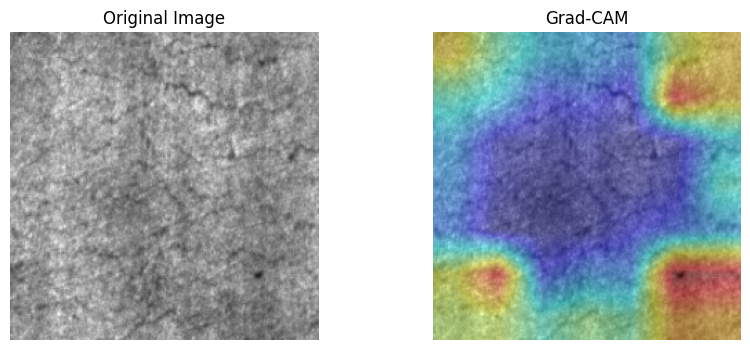

In [58]:
show_gradcam('/content/image resized/Cr_120.bmp')

#TfLite

In [59]:
loaded_model = tf_keras.models.load_model(
    "/content/crack_detector_mobilenet.h5",
    custom_objects={'KerasLayer': hub.KerasLayer}
)


In [60]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
tflite_model = converter.convert()

with open("crack_detector_float32.tflite", "wb") as f:
    f.write(tflite_model)

print("Float32 TFLite model saved!")


Float32 TFLite model saved!


In [61]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quant_model = converter.convert()

with open("crack_detector_quant.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Quantized TFLite model saved!")


Quantized TFLite model saved!


In [62]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter.convert()

with open("crack_detector_fp16.tflite", "wb") as f:
    f.write(tflite_fp16)

print("FP16 GPU-friendly TFLite model saved!")


FP16 GPU-friendly TFLite model saved!


In [63]:
def tflite_predict(tflite_path, image_path):
    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Load & preprocess image
    img = Image.open(image_path).resize((224,224)).convert("RGB")
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0).astype(np.float32)

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output)

    print(f"TFLite Prediction: {'Crack' if pred==1 else 'Non-crack'}")
    return pred


In [64]:
tflite_predict("crack_detector_quant.tflite", "/content/image resized/Cr_120.bmp")


TFLite Prediction: Crack


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


np.int64(1)